*  DSC640-T301 Data Presentation & Visualizat (2263-1)
*  Term Project - Milestone 5
*  Charles Sarratt

# Milestone 5 Final Submission

This notebook contains the calculations and Python-generated visuals used to support the final Milestone 5 deliverables:
1. **Presentation (PDF)**: Narrative slides using county-level affordability ratios (2018).
2. **Dashboard (PDF, static submission layout)**: KPI metrics, state tile map, and WA county ranking table.
3. **Infographic (PDF)**: Executive summary layout synthesizing key metrics and implications.

Note: The dashboard and infographic layouts were finalized in PowerPoint for medium separation and readability. This notebook generates the underlying metrics and visual components used in those final layouts.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
file_path = "nationaldatabaseofchildcareprices.xlsx"
df = pd.read_excel(file_path)

df.head()

# Output folder for images
OUT_DIR = "milestone3_charts"
os.makedirs(OUT_DIR, exist_ok=True)

def save_fig(fig, filename, dpi=300):
    path = os.path.join(OUT_DIR, filename)
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    return path

# Ensure column names are standardized (safe to re-run)
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

required_cols = ["mcinfant", "mctoddler", "mfccinfant", "mfcctoddler", "mhi"]
missing_required = [c for c in required_cols if c not in df.columns]
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

if "ratio_infant_center" not in df.columns:
    df["ratio_infant_center"] = df["mcinfant"] / df["mhi"]
if "ratio_toddler_center" not in df.columns:
    df["ratio_toddler_center"] = df["mctoddler"] / df["mhi"]
if "ratio_infant_family" not in df.columns:
    df["ratio_infant_family"] = df["mfccinfant"] / df["mhi"]
if "ratio_toddler_family" not in df.columns:
    df["ratio_toddler_family"] = df["mfcctoddler"] / df["mhi"]

# Use a single year to avoid mixing counties across time for state and county comparisons
latest_year = int(df["studyyear"].max())
df_latest = df[df["studyyear"] == latest_year].copy()

latest_year

2018

## Chart 1: National Affordability Context
Distribution of county affordability ratios for infant center-based care (latest year).

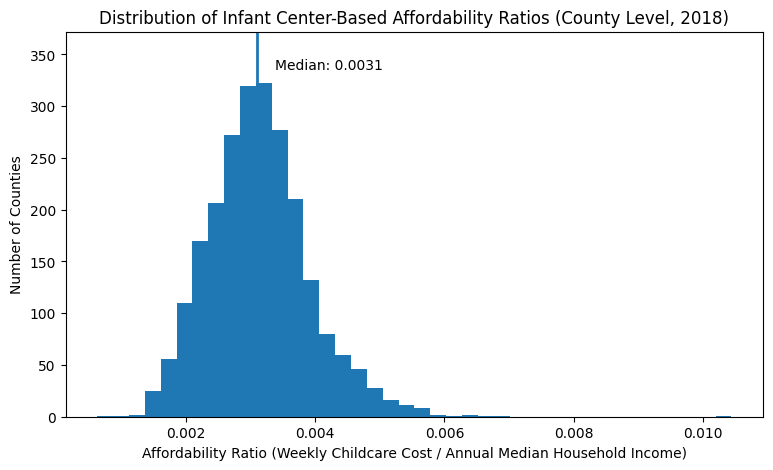

'milestone3_charts\\chart1_affordability_distribution_2018.png'

In [2]:
vals = df_latest["ratio_infant_center"].dropna()

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(vals, bins=40)
ax.set_title(f"Distribution of Infant Center-Based Affordability Ratios (County Level, {latest_year})")
ax.set_xlabel("Affordability Ratio (Weekly Childcare Cost / Annual Median Household Income)")
ax.set_ylabel("Number of Counties")

median_val = vals.median()
ax.axvline(median_val, linewidth=2)

# Add headroom so annotations do not crowd the bars
ymax = ax.get_ylim()[1]
ax.set_ylim(0, ymax * 1.10)

# Place label near the top using axes coordinates (prevents overlap)
ax.text(
    0.30, 0.93,
    f"Median: {median_val:.4f}",
    transform=ax.transAxes,
    ha="left",
    va="top"
)

path1 = save_fig(fig, f"chart1_affordability_distribution_{latest_year}.png")
plt.show()

path1

## Chart 2: States with the Highest Childcare Burden
Top 10 states by mean infant center-based affordability ratio (latest year).

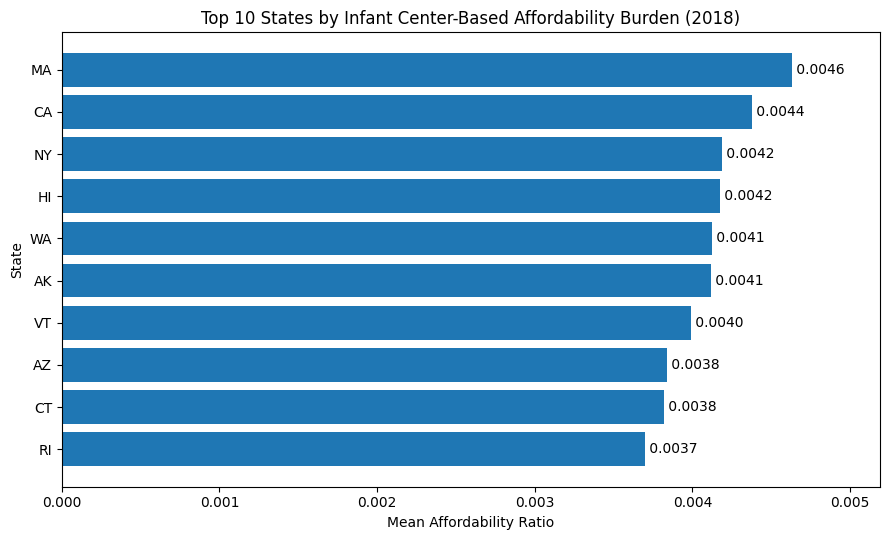

'milestone3_charts\\chart2_top10_states_affordability_2018.png'

In [3]:
state_afford = (
    df_latest.groupby("state_abbreviation")[["ratio_infant_center"]]
    .mean()
    .dropna()
    .sort_values("ratio_infant_center", ascending=False)
)

top10 = state_afford.head(10).sort_values("ratio_infant_center", ascending=True)

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.barh(top10.index, top10["ratio_infant_center"].values)
ax.set_title(f"Top 10 States by Infant Center-Based Affordability Burden ({latest_year})")
ax.set_xlabel("Mean Affordability Ratio")
ax.set_ylabel("State")

# Give extra room on the right so labels never clip
max_val = top10["ratio_infant_center"].max()
ax.set_xlim(0, max_val * 1.12)

for y, v in enumerate(top10["ratio_infant_center"].values):
    ax.text(v, y, f" {v:.4f}", va="center")

# Add padding so nothing gets cut off when saved
fig.tight_layout()

path2 = save_fig(fig, f"chart2_top10_states_affordability_{latest_year}.png")
plt.show()

path2

## Chart 3: Price vs Income Relationship
County median household income vs infant center-based weekly childcare price (latest year).

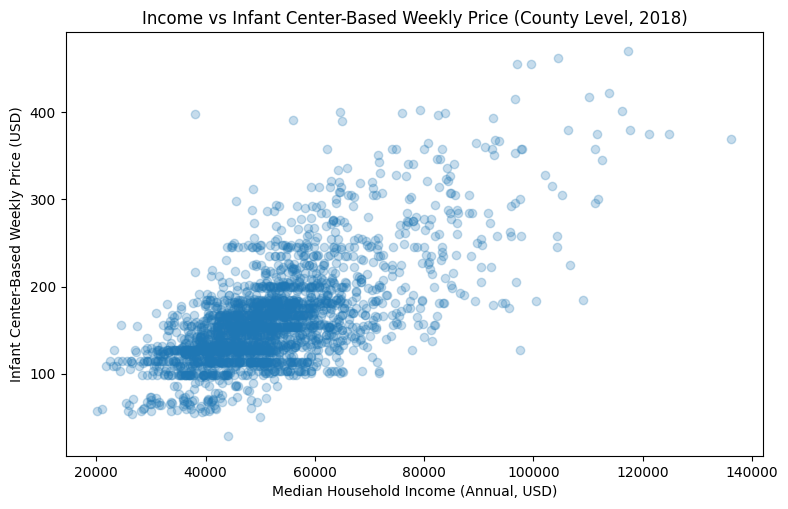

'milestone3_charts\\chart3_income_vs_price_scatter_2018.png'

In [4]:
scatter_df = df_latest[["mhi", "mcinfant"]].dropna()

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.scatter(scatter_df["mhi"], scatter_df["mcinfant"], alpha=0.25)

ax.set_title(f"Income vs Infant Center-Based Weekly Price (County Level, {latest_year})")
ax.set_xlabel("Median Household Income (Annual, USD)")
ax.set_ylabel("Infant Center-Based Weekly Price (USD)")

path3 = save_fig(fig, f"chart3_income_vs_price_scatter_{latest_year}.png")
plt.show()

path3

## Chart 4: Infant vs Toddler Care Burden
Compare mean affordability ratios for infant vs toddler center-based care (latest year).

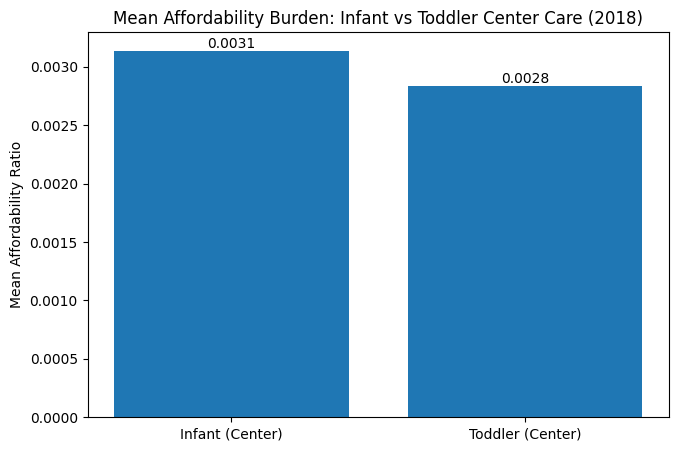

'milestone3_charts\\chart4_infant_vs_toddler_burden_2018.png'

In [5]:
mean_infant = df_latest["ratio_infant_center"].mean()
mean_toddler = df_latest["ratio_toddler_center"].mean()

fig, ax = plt.subplots(figsize=(7.5, 5))
categories = ["Infant (Center)", "Toddler (Center)"]
values = [mean_infant, mean_toddler]

ax.bar(categories, values)
ax.set_title(f"Mean Affordability Burden: Infant vs Toddler Center Care ({latest_year})")
ax.set_ylabel("Mean Affordability Ratio")

for i, v in enumerate(values):
    ax.text(i, v, f"{v:.4f}", ha="center", va="bottom")

path4 = save_fig(fig, f"chart4_infant_vs_toddler_burden_{latest_year}.png")
plt.show()

path4

## Chart 5: County-Level Variation Within a State
This view illustrates how a statewide average can mask county-level variation.
State chosen: Washington (WA) because it appears consistently high on affordability burden.
Latest year only.

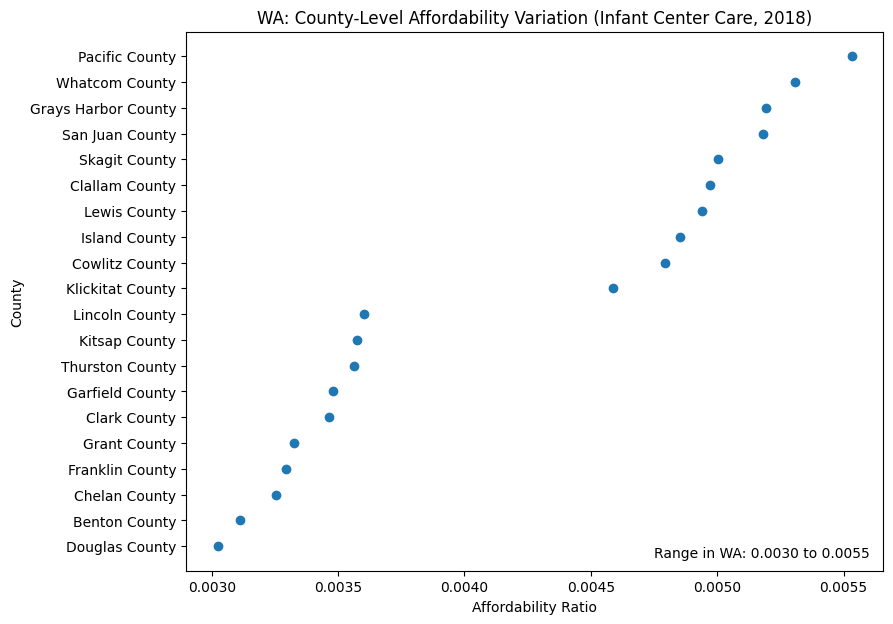

'milestone3_charts\\chart5_county_variation_WA_2018.png'

In [6]:
STATE_FOR_COUNTY_VIEW = "WA"

county_df = (
    df_latest[df_latest["state_abbreviation"] == STATE_FOR_COUNTY_VIEW]
    [["county_name", "ratio_infant_center"]]
    .dropna()
)

county_sorted = county_df.sort_values("ratio_infant_center", ascending=False)
top_n = 10

top_part = county_sorted.head(top_n)
bottom_part = county_sorted.tail(top_n)
county_view = pd.concat([top_part, bottom_part]).drop_duplicates()

county_view = county_view.sort_values("ratio_infant_center", ascending=True)

fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(county_view["ratio_infant_center"], county_view["county_name"])

ax.set_title(f"{STATE_FOR_COUNTY_VIEW}: County-Level Affordability Variation (Infant Center Care, {latest_year})")
ax.set_xlabel("Affordability Ratio")
ax.set_ylabel("County")

min_v = county_sorted["ratio_infant_center"].min()
max_v = county_sorted["ratio_infant_center"].max()
ax.text(0.98, 0.02, f"Range in {STATE_FOR_COUNTY_VIEW}: {min_v:.4f} to {max_v:.4f}",
        transform=ax.transAxes, ha="right", va="bottom")

path5 = save_fig(fig, f"chart5_county_variation_{STATE_FOR_COUNTY_VIEW}_{latest_year}.png")
plt.show()

path5

## Final Dashboard Components (Milestone 5 Submission)
The final dashboard submitted for Milestone 5 is a static decision-support view. This notebook generates the three dashboard components used in that layout:

- KPI cards (national mean, national median, highest-burden state, WA county range)
- State tile map shaded by infant center affordability ratio (2018)
- WA county ranking table (infant center affordability ratio, 2018)

In [9]:
# --- Dashboard Prep: State-level summary (Infant Center, 2018) ---

YEAR = 2018

df_2018 = df[df["studyyear"] == YEAR].copy()

# State mean affordability ratios (already created in your earlier analysis, but we re-derive cleanly)
state_afford = (
    df_2018.groupby("state_abbreviation")[["ratio_infant_center", "ratio_toddler_center"]]
    .mean()
    .sort_values(by="ratio_infant_center", ascending=False)
)

# National summary stats
national_mean = df_2018["ratio_infant_center"].mean()
national_median = df_2018["ratio_infant_center"].median()

# Highest-burden state (mean ratio)
highest_state = state_afford["ratio_infant_center"].idxmax()
highest_state_value = state_afford.loc[highest_state, "ratio_infant_center"]

national_mean, national_median, highest_state, highest_state_value

(np.float64(0.0031373768802671026),
 0.0030956151877407794,
 'MA',
 np.float64(0.004634174787853949))

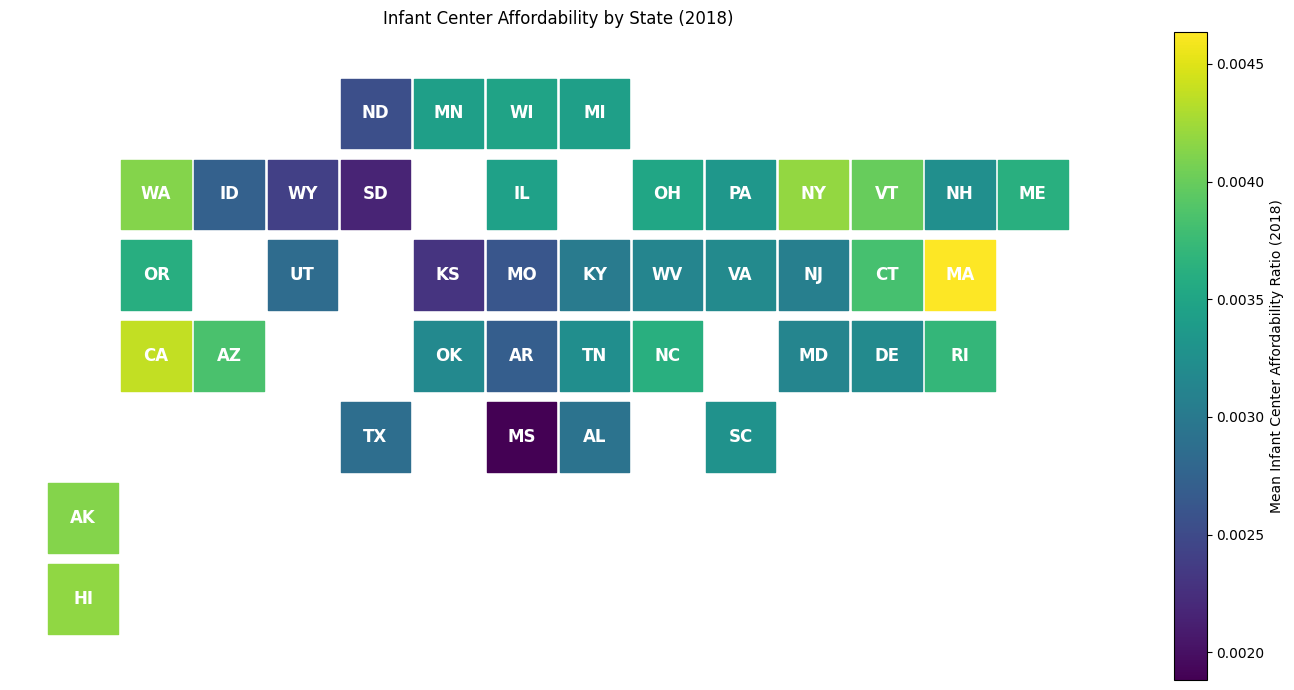

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# --- State tile grid positions (approximate US layout) ---
# This is a common “tile map” layout used when shapefiles are not available.
tile_pos = {
    "WA": (0, 5), "OR": (0, 4), "CA": (0, 3),
    "ID": (1, 5), "NV": (1, 4), "AZ": (1, 3),
    "MT": (2, 6), "WY": (2, 5), "UT": (2, 4), "NM": (2, 3),
    "ND": (3, 6), "SD": (3, 5), "CO": (3, 4), "TX": (3, 2),
    "MN": (4, 6), "IA": (4, 5), "KS": (4, 4), "OK": (4, 3), "LA": (4, 2),
    "WI": (5, 6), "IL": (5, 5), "MO": (5, 4), "AR": (5, 3), "MS": (5, 2),
    "MI": (6, 6), "IN": (6, 5), "KY": (6, 4), "TN": (6, 3), "AL": (6, 2),
    "OH": (7, 5), "WV": (7, 4), "NC": (7, 3), "GA": (7, 2), "FL": (7, 1),
    "PA": (8, 5), "VA": (8, 4), "SC": (8, 2),
    "NY": (9, 5), "NJ": (9, 4), "MD": (9, 3), "DC": (9, 2),
    "CT": (10, 4), "DE": (10, 3),
    "MA": (11, 4), "RI": (11, 3),
    "VT": (10, 5), "NH": (11, 5), "ME": (12, 5),

    # Non-contiguous placed off to the side
    "AK": (-1, 1), "HI": (-1, 0),
}

# Pull state metric
state_metric = state_afford["ratio_infant_center"].copy()

# Build arrays for plotting
states = []
xs, ys, vals = [], [], []
for st, (x, y) in tile_pos.items():
    if st in state_metric.index:
        states.append(st)
        xs.append(x)
        ys.append(y)
        vals.append(state_metric.loc[st])

xs = np.array(xs)
ys = np.array(ys)
vals = np.array(vals)

fig, ax = plt.subplots(figsize=(14, 7))

# Draw tiles
sc = ax.scatter(xs, ys, c=vals, s=2500, marker="s")

# Labels on tiles
for st, x, y in zip(states, xs, ys):
    ax.text(x, y, st, ha="center", va="center", fontsize=12, fontweight="bold", color="white")

# Colorbar
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Mean Infant Center Affordability Ratio (2018)")

ax.set_title("Infant Center Affordability by State (2018)")
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlim(-2, 13)
ax.set_ylim(-1, 7)
ax.set_frame_on(False)

plt.tight_layout()
plt.savefig("dashboard_tilemap_state_affordability_2018.png", dpi=200)
plt.show()

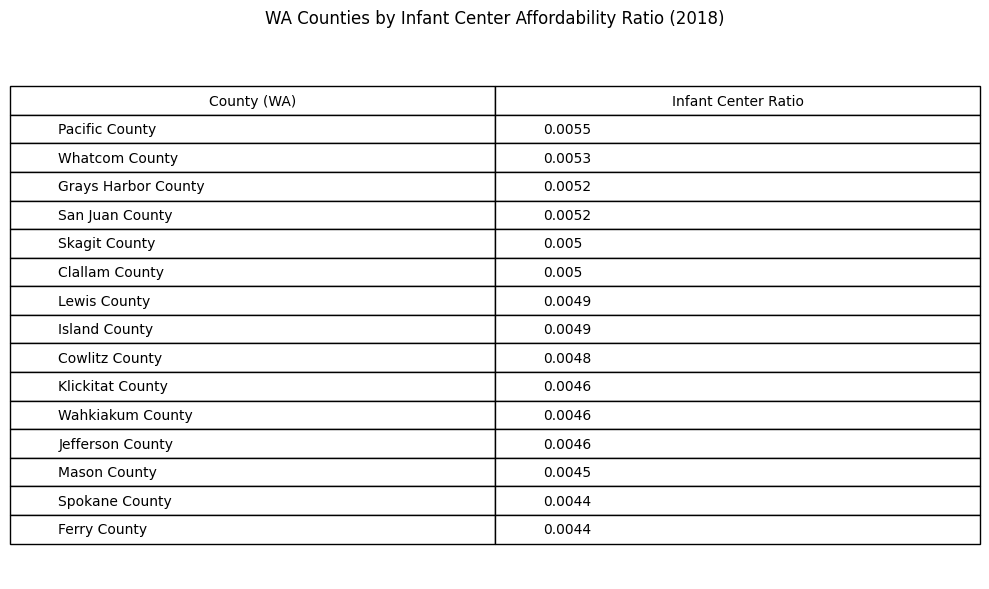

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# --- WA county ranking table (Infant Center, 2018) ---
wa = df_2018[df_2018["state_abbreviation"] == "WA"].copy()

wa_county = (
    wa.groupby("county_name")["ratio_infant_center"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

# Keep top 15 for readability
wa_top = wa_county.head(15).copy()
wa_top["ratio_infant_center"] = wa_top["ratio_infant_center"].round(4)

fig, ax = plt.subplots(figsize=(10, 6))
ax.axis("off")

tbl = ax.table(
    cellText=wa_top.values,
    colLabels=["County (WA)", "Infant Center Ratio"],
    cellLoc="left",
    loc="center"
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 1.5)

ax.set_title("WA Counties by Infant Center Affordability Ratio (2018)", pad=20)

plt.tight_layout()
plt.savefig("dashboard_wa_county_table_2018.png", dpi=200)
plt.show()

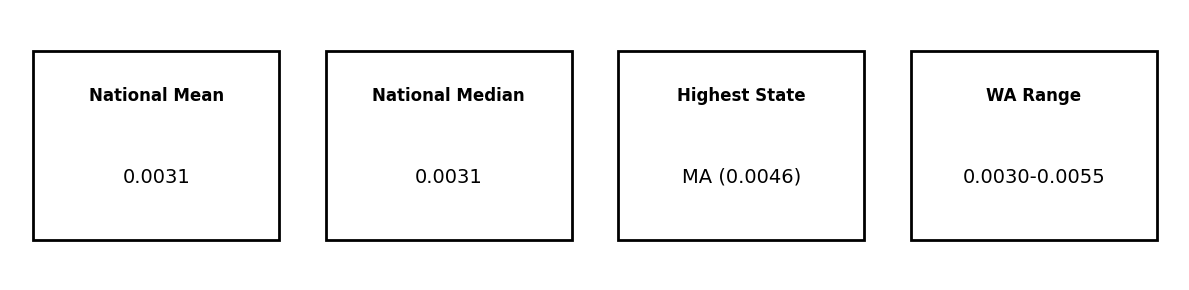

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# WA range
wa_min = wa["ratio_infant_center"].min()
wa_max = wa["ratio_infant_center"].max()

kpis = [
    ("National Mean", f"{national_mean:.4f}"),
    ("National Median", f"{national_median:.4f}"),
    ("Highest State", f"{highest_state} ({highest_state_value:.4f})"),
    ("WA Range", f"{wa_min:.4f}-{wa_max:.4f}")
]

fig, ax = plt.subplots(figsize=(12, 3))
ax.axis("off")

# Card layout
x_positions = [0.02, 0.27, 0.52, 0.77]
for (label, value), x in zip(kpis, x_positions):
    ax.add_patch(plt.Rectangle((x, 0.15), 0.21, 0.7, fill=False, linewidth=2))
    ax.text(x + 0.105, 0.68, label, ha="center", va="center", fontsize=12, fontweight="bold")
    ax.text(x + 0.105, 0.38, value, ha="center", va="center", fontsize=14)

plt.tight_layout()
plt.savefig("dashboard_kpi_cards_2018.png", dpi=200)
plt.show()

## Final Infographic (Milestone 5 Submission)
The final infographic is a one-page executive summary created in PowerPoint to ensure a distinct medium and avoid visual overlap with the presentation and dashboard.

It uses the KPI values computed in this notebook:
- National mean affordability ratio (infant center, 2018)
- National median affordability ratio (infant center, 2018)
- Highest-burden state (mean infant center affordability ratio, 2018)
- WA county affordability ratio range (min to max, 2018)

The infographic layout and wording are finalized in the submitted PDF.